In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [4]:
df['median_house_value'].value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
359200.0      1
54900.0       1
377600.0      1
81200.0       1
47000.0       1
Name: count, Length: 3842, dtype: int64

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [7]:
print(df.isnull().sum(), '\n', df.duplicated().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64 
 0


In [8]:
mean = df['total_bedrooms'].mean()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mean)

In [9]:
unique = df['ocean_proximity'].unique()
print(unique)

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [10]:
# one hot encoding cuz there's many
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype= int)

In [11]:
print(df.isnull().sum(), '\n', df.duplicated().sum(), '\n', df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  int64  
 10  ocean_proximity_INLAND      20640 non-null  int64  
 11  ocean_proximity_ISLAND      20640 non-null  int64  
 12  ocean_proximity_NEAR BAY    20640 non-null  int64  
 13  ocean_proximity_NEAR OCEAN  206

In [12]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

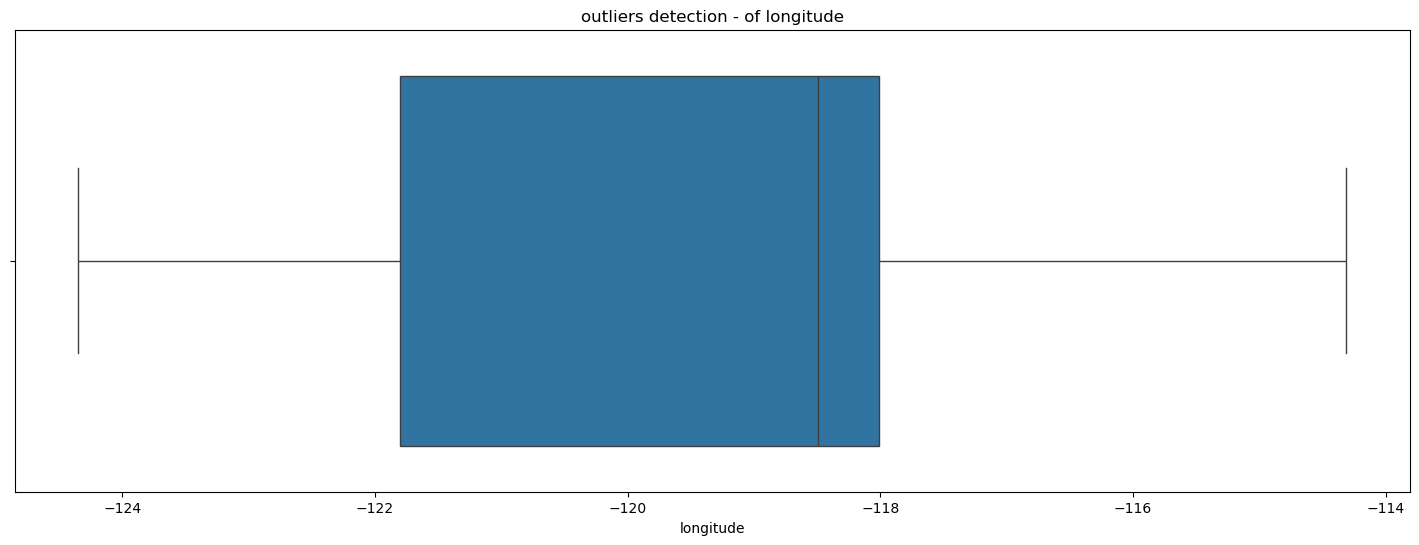

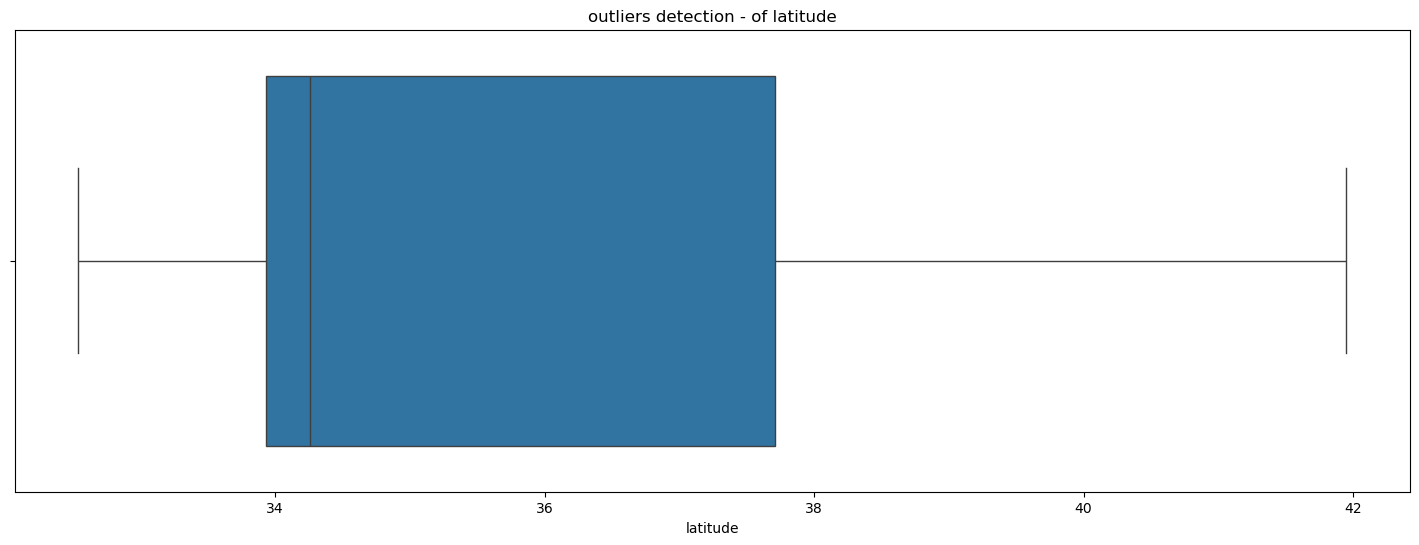

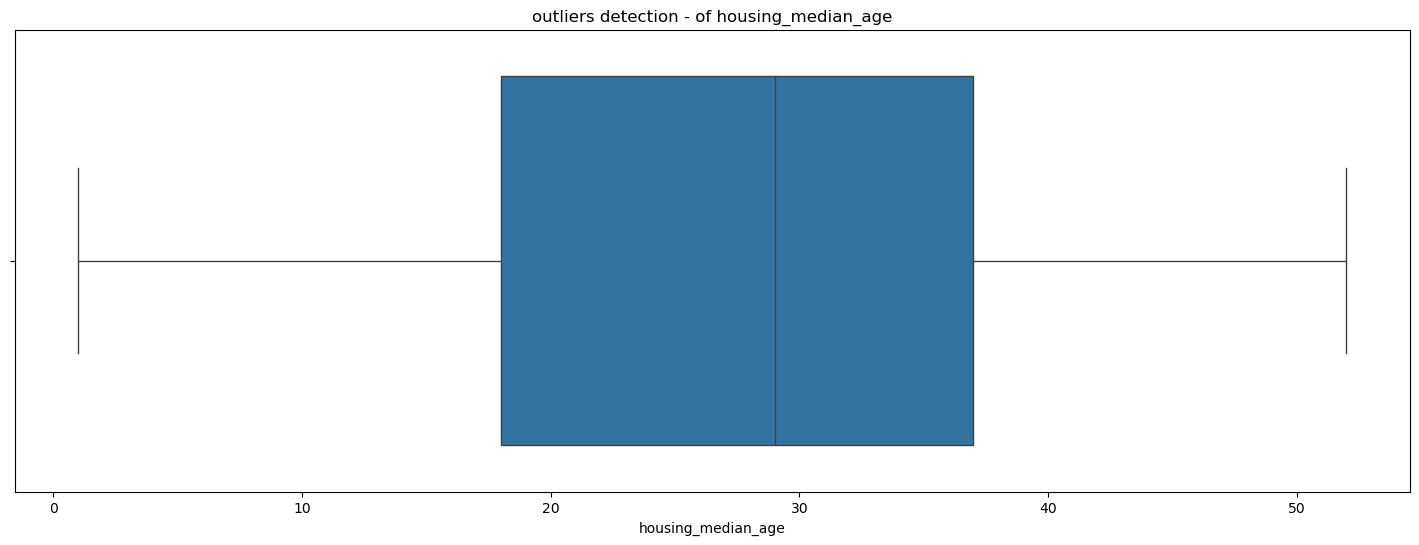

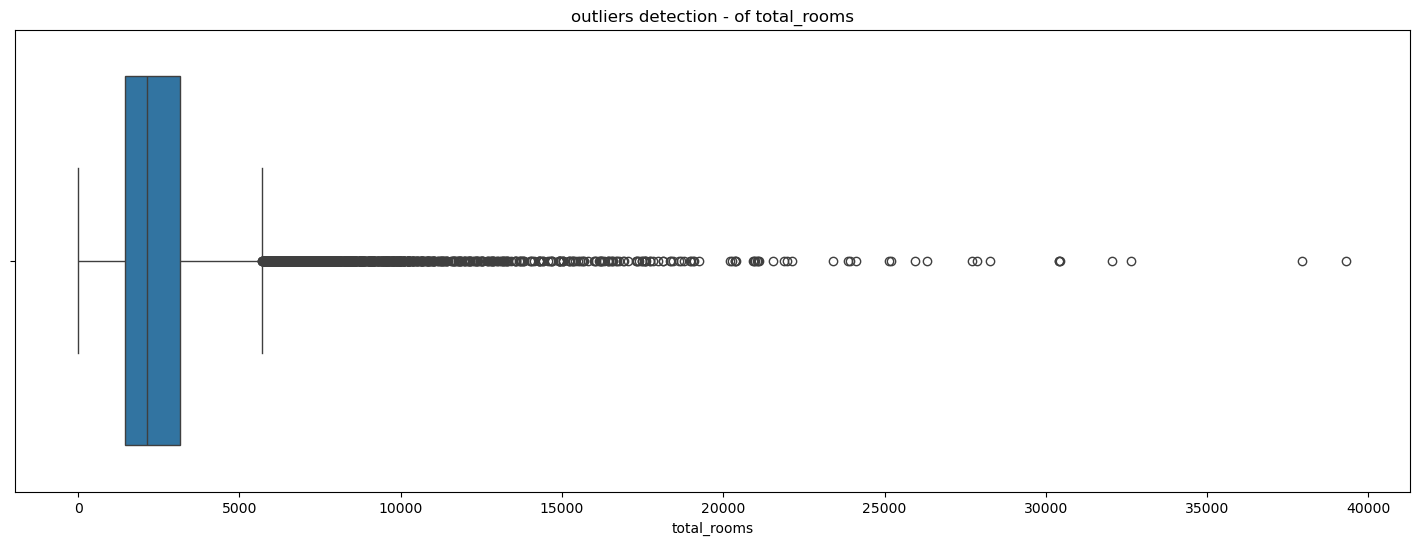

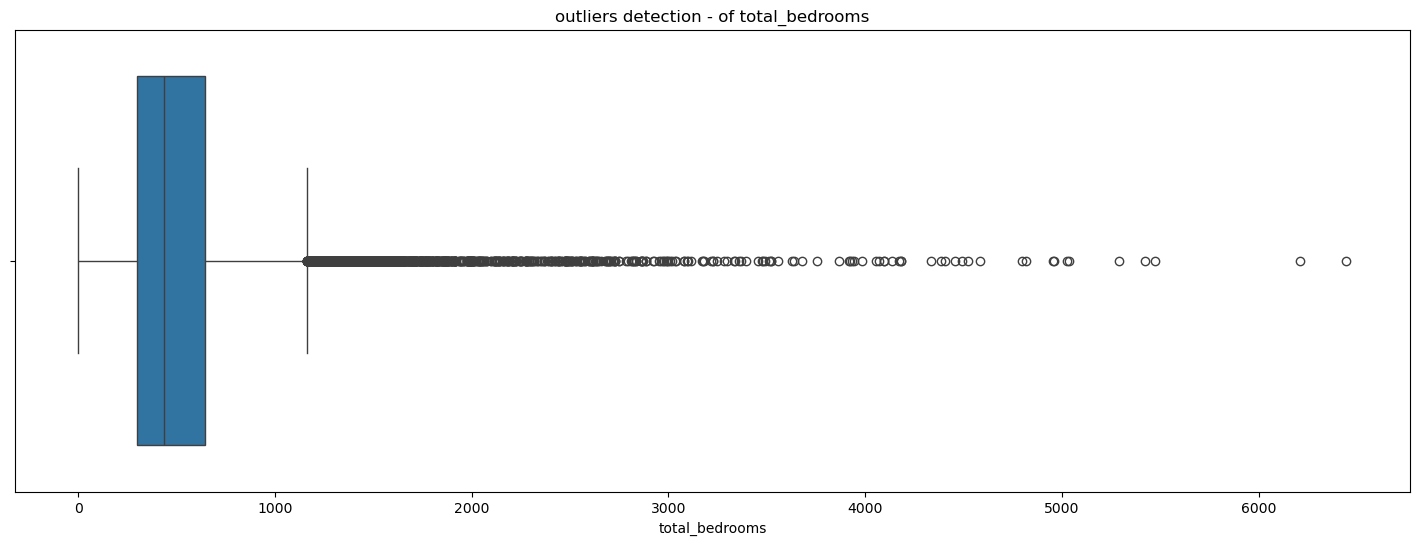

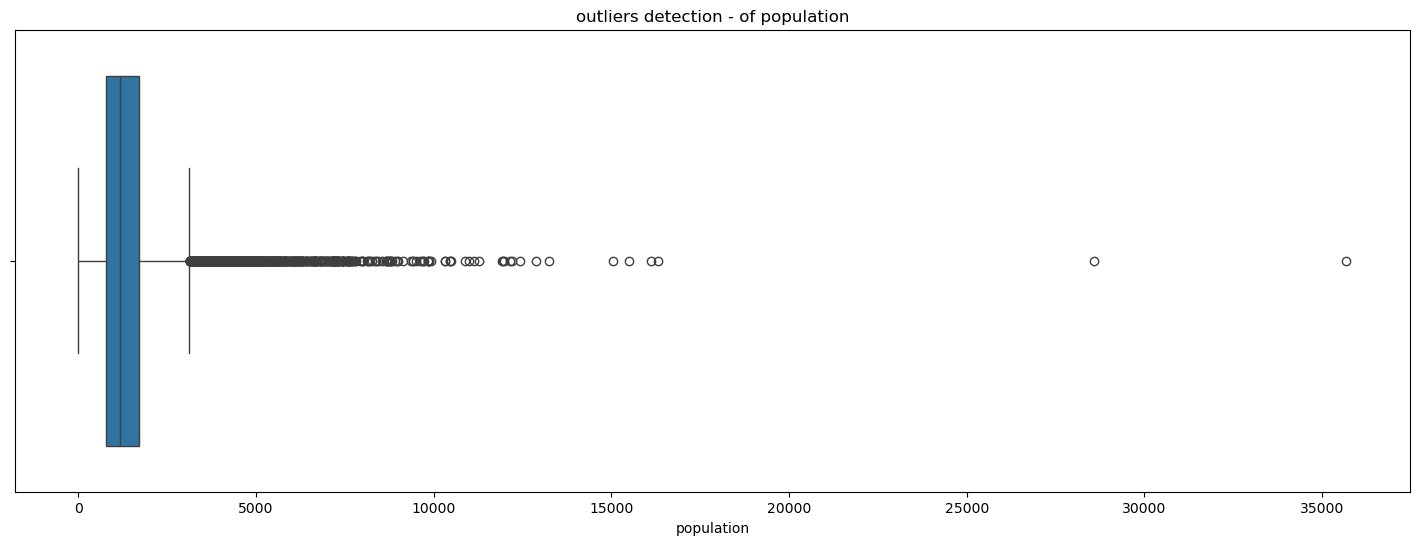

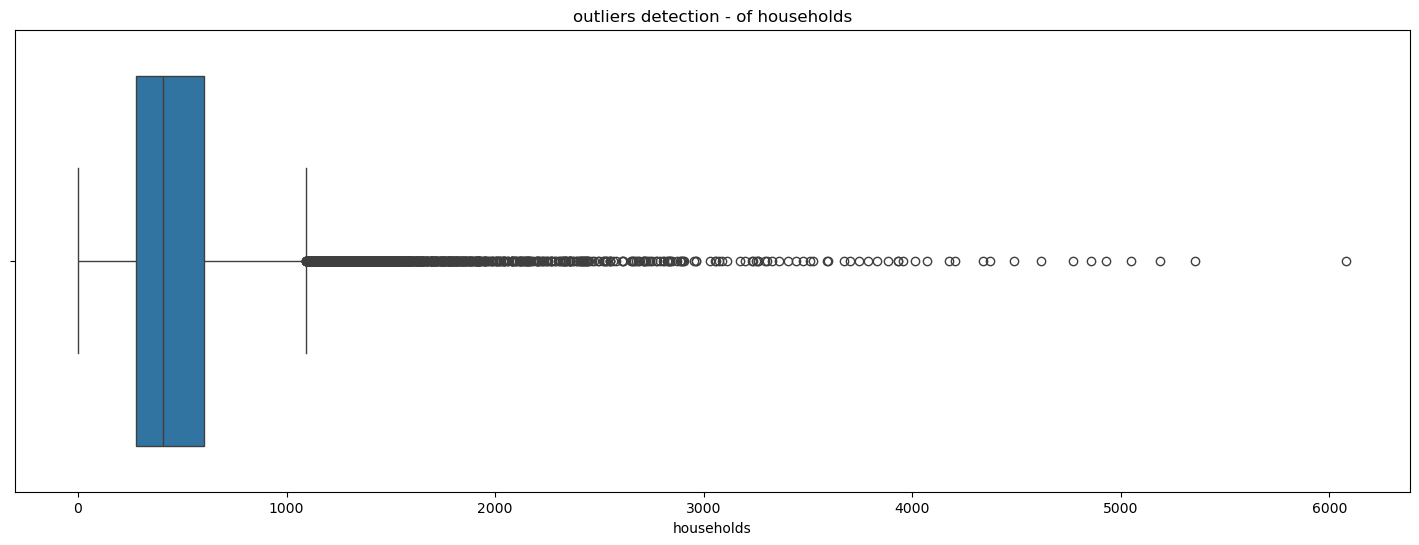

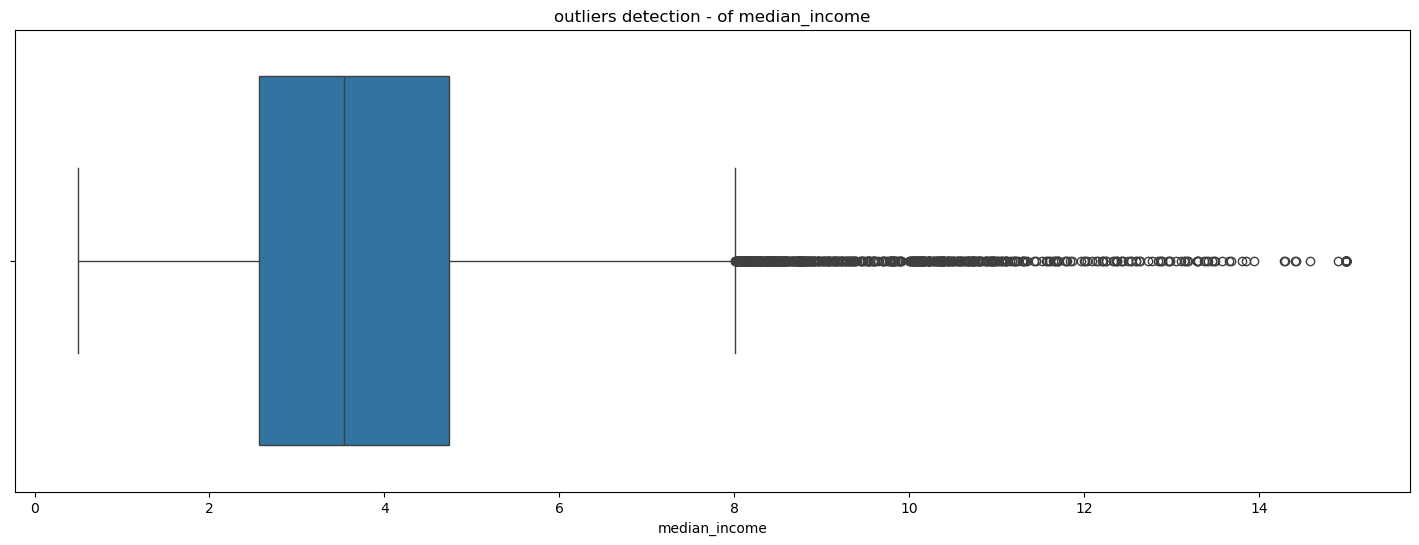

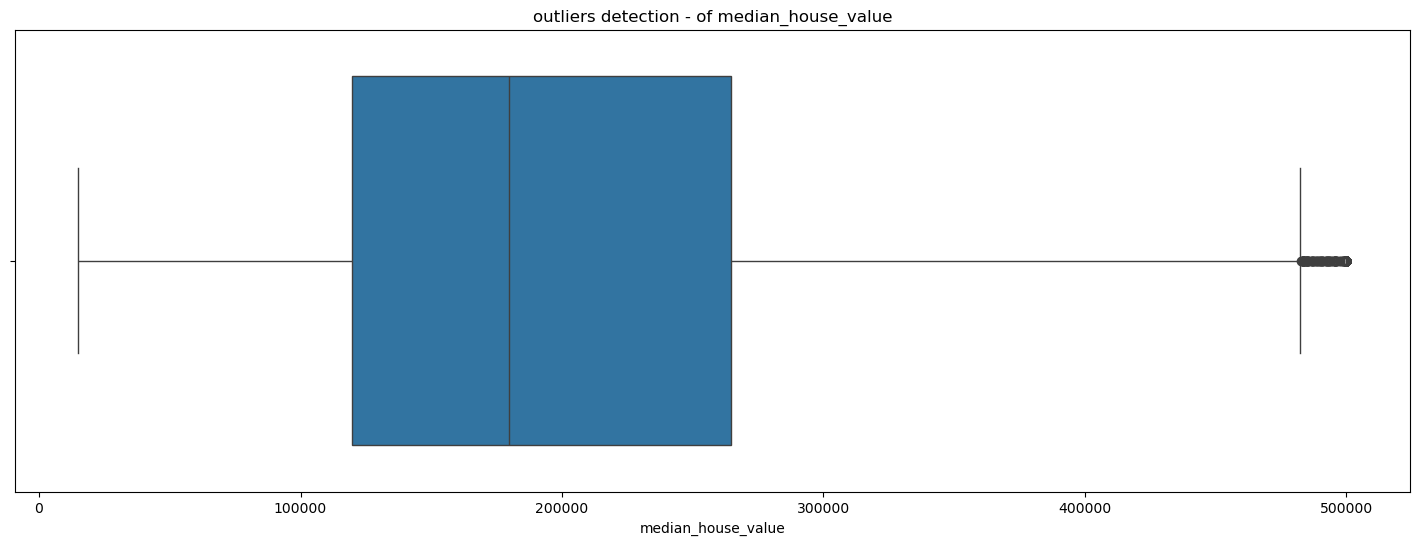

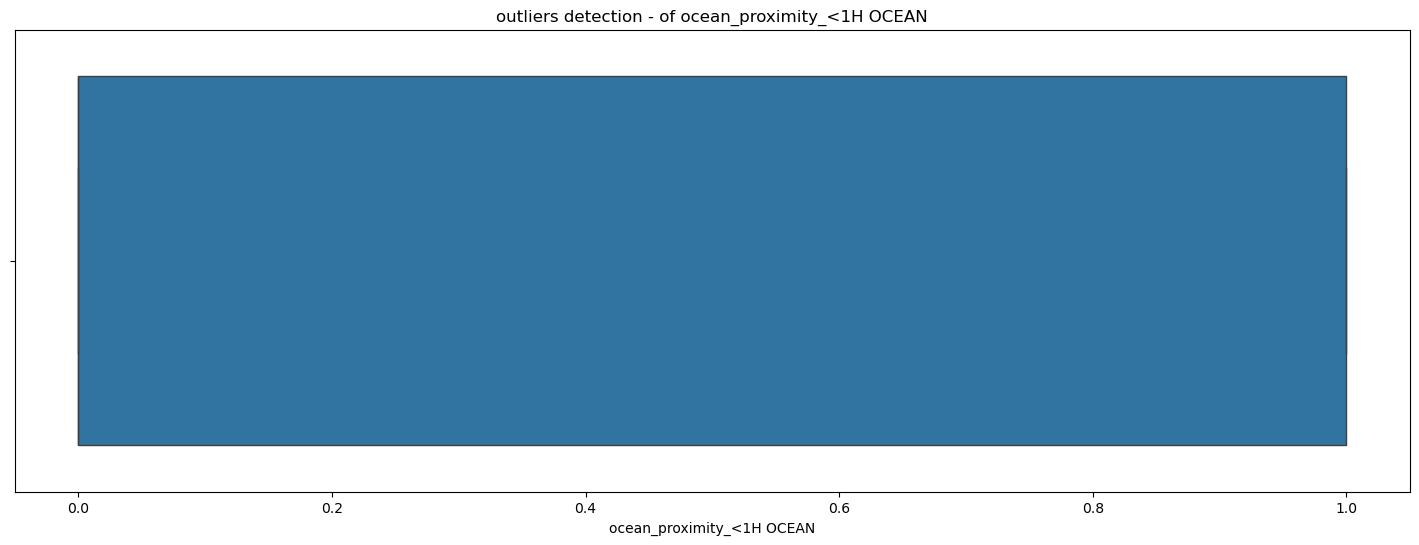

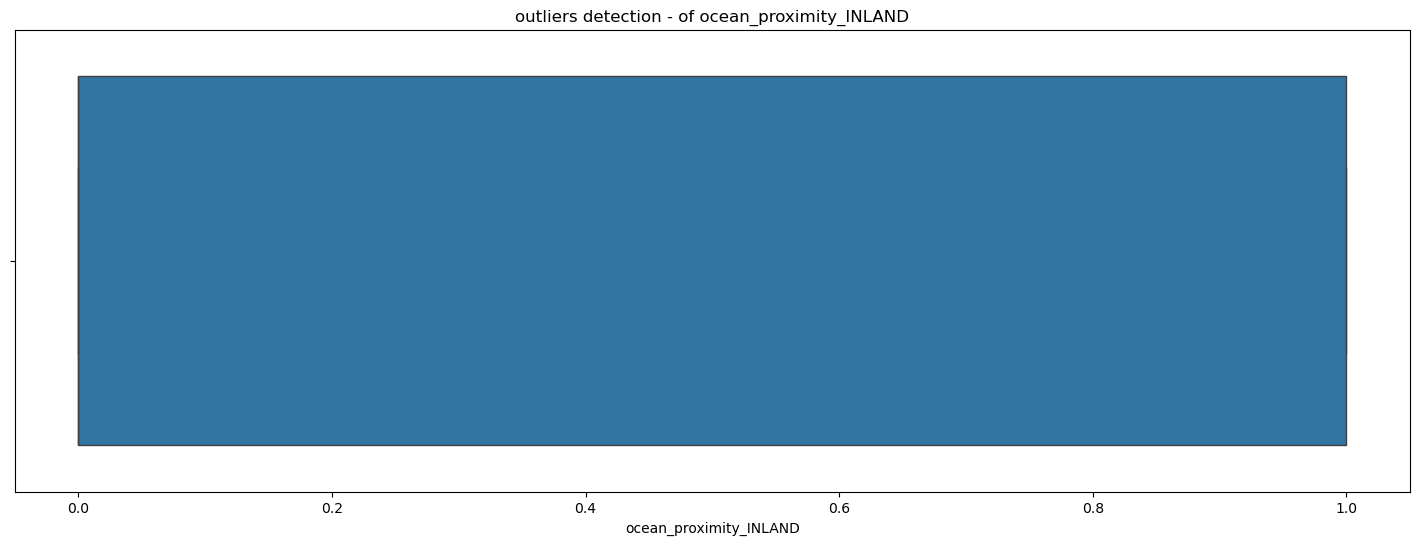

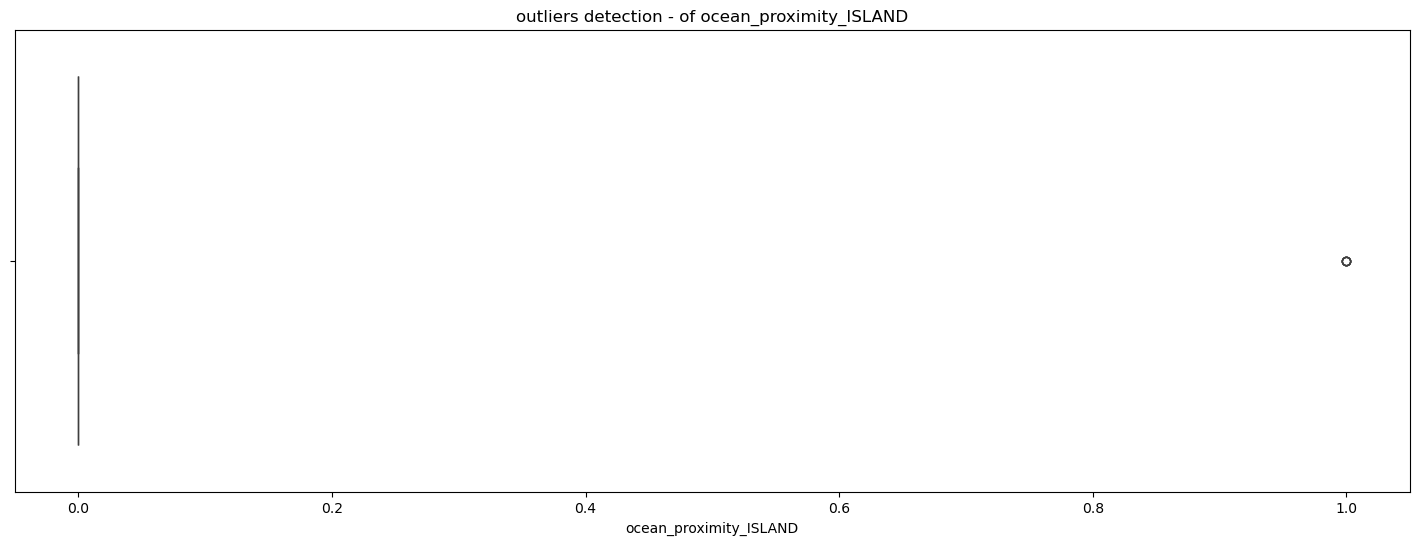

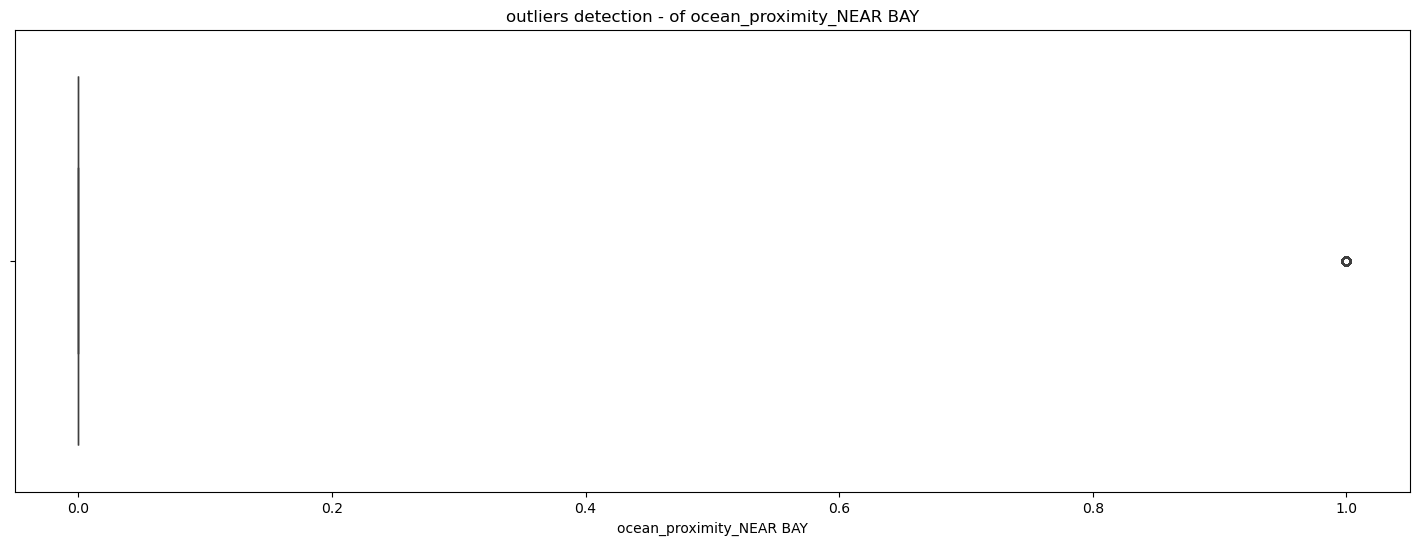

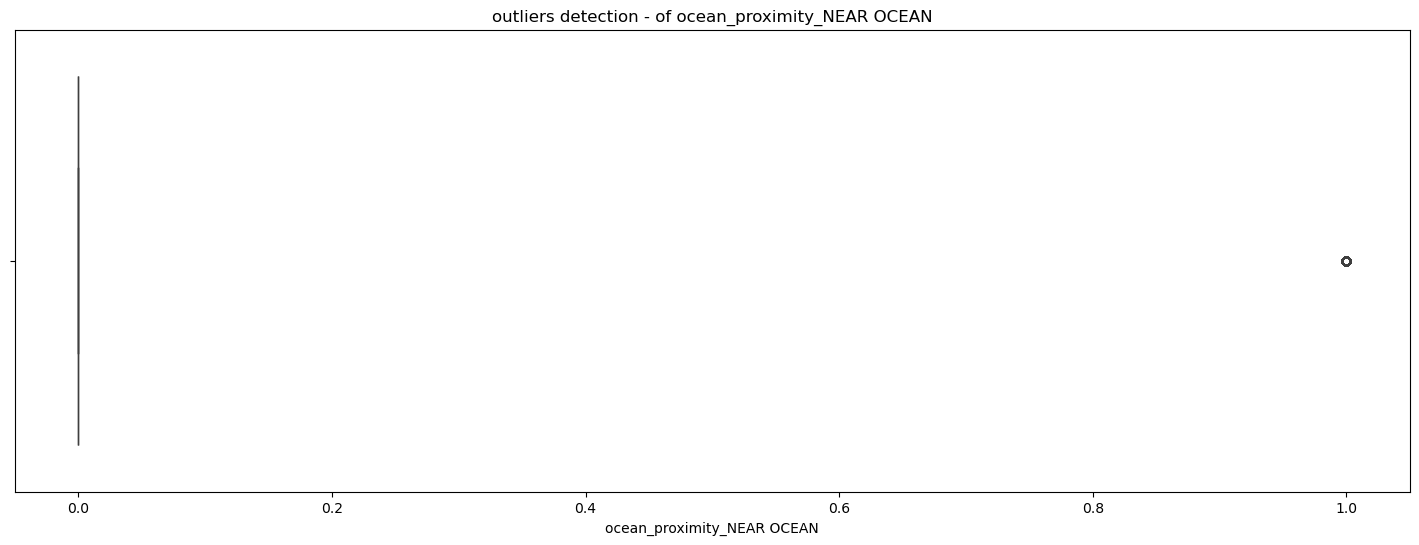

In [13]:
for col in columns:
    plt.figure(figsize=(18,6))
    sns.boxplot(x=df[col])
    plt.title(f'outliers detection - of {col}')
    plt.show()

In [14]:
# noticed which columns have outliers, the ones with too many outliers will use lo transformation while the less ones can be removed if not imp
# import numpy for log transformation

In [15]:
df[['total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']] = np.log1p(df[['total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']])

In [16]:
# drop the very few outliers
means = df['ocean_proximity_ISLAND'].mean()
std = df['ocean_proximity_ISLAND'].std()
df['z_score'] = (df['ocean_proximity_ISLAND'] - means) / std
df = df[df['ocean_proximity_ISLAND'].abs()<3].drop(columns = ['z_score'])

In [17]:
#feature engineering, i'll create a pricing mean according to location
#first grouping the nearby houses
kmeans = KMeans(n_clusters=15, random_state=42)
df['geo_clusters'] = kmeans.fit_predict(df[['latitude', 'longitude']])

In [18]:
#now we make a new row called location, in accordance with the ocean
ocean_dist= df[['ocean_proximity_<1H OCEAN','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']].idxmax(axis=1)
ocean_dist = ocean_dist.str.replace('ocean_proximity_', '')
df['location'] = df['geo_clusters'].astype(str)+ '_'+ ocean_dist

In [19]:
#lastly we make a mean of prices in this area range
zone = df.groupby('location')['median_house_value'].mean()
df['area_prices'] = df['location'].map(zone)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,geo_clusters,location,area_prices
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,2.232720,13.022766,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,2.230165,12.789687,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,2.111110,12.771673,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,1.893579,12.740520,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,1.578195,12.743154,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,0.940124,11.265758,0,1,0,0.000000,0.0,8,8_INLAND,11.702215
20636,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,1.268861,11.252872,0,1,0,0.000000,0.0,8,8_INLAND,11.702215
20637,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,0.993252,11.432810,0,1,0,0.000000,0.0,8,8_INLAND,11.702215
20638,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.053336,11.346883,0,1,0,0.000000,0.0,8,8_INLAND,11.702215


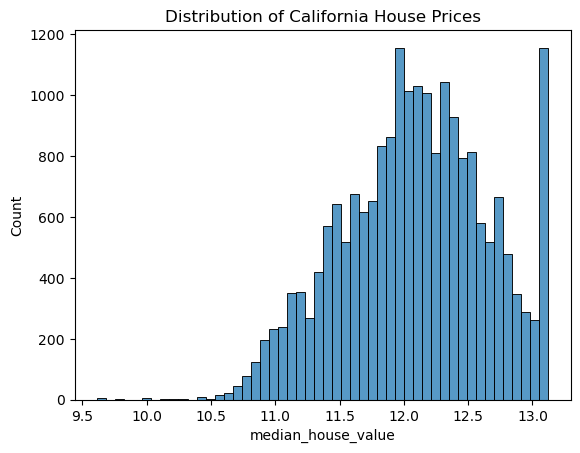

In [20]:
# Plotting the distribution of house prices
sns.histplot(df['median_house_value'], bins=50, kde=False)
plt.title("Distribution of California House Prices")
plt.show()
# the data is still highly right skewed although outliers deleted cause it's capped at max value, so prices won't overgo it

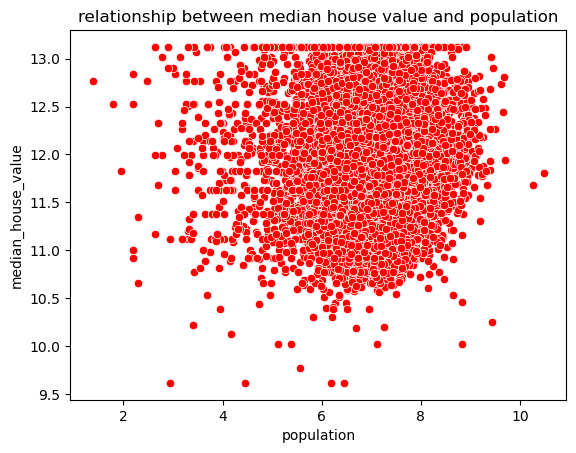

In [21]:
#this was bcz i wanted to see the relationship between two variables hence its called bivariate
sns.scatterplot(x='population', y='median_house_value', color='red', data=df)
plt.title('relationship between median house value and population')
plt.show()

<Axes: >

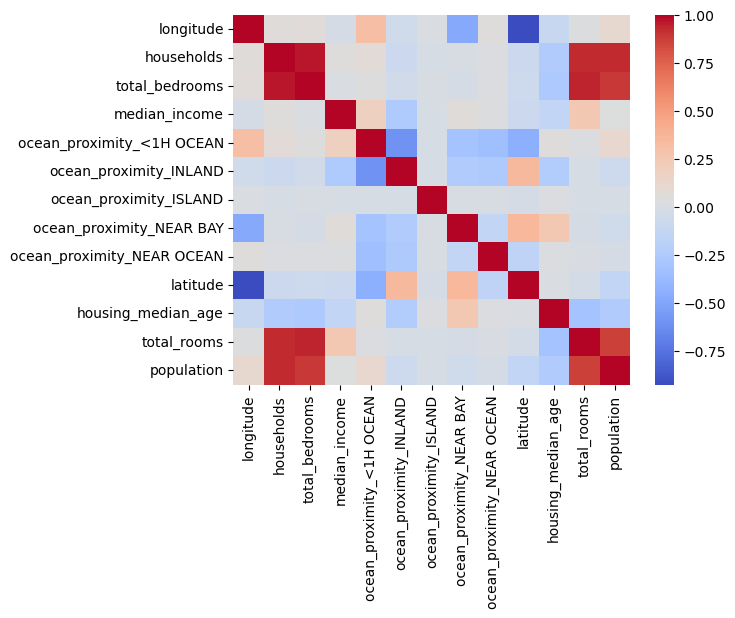

In [22]:
# checking the correlation between them all
num_col = df[['longitude','households','total_bedrooms','median_income','ocean_proximity_<1H OCEAN','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN','latitude','housing_median_age','total_rooms','population']]
correlations = num_col.corr()
sns.heatmap(data = correlations, cmap= "coolwarm", fmt = '.2f')

In [23]:
#x_before = df[['longitude','households','total_bedrooms','median_income','ocean_proximity_<1H OCEAN','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN','latitude','housing_median_age','total_rooms','population']]
x = df[['longitude','households','median_income','ocean_proximity_INLAND','ocean_proximity_<1H OCEAN','latitude','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','housing_median_age','total_rooms','population']]
y = df['median_house_value']

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
df #checking for large numbers to scale

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,geo_clusters,location,area_prices
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,2.232720,13.022766,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,2.230165,12.789687,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,2.111110,12.771673,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,1.893579,12.740520,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,1.578195,12.743154,0,0,0,0.693147,0.0,12,12_NEAR BAY,12.351098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,0.940124,11.265758,0,1,0,0.000000,0.0,8,8_INLAND,11.702215
20636,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,1.268861,11.252872,0,1,0,0.000000,0.0,8,8_INLAND,11.702215
20637,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,0.993252,11.432810,0,1,0,0.000000,0.0,8,8_INLAND,11.702215
20638,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.053336,11.346883,0,1,0,0.000000,0.0,8,8_INLAND,11.702215


In [25]:
df = df.round(2)

In [26]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
predictions = model.predict(x_test)

In [28]:
MAE = (mean_absolute_error(y_test, predictions)).__round__(2)
RMSE = (root_mean_squared_error(y_test, predictions)).__round__(2)
r2 = (r2_score(y_test, predictions)).__round__(2)
MAPE = ((mean_absolute_percentage_error(y_test, predictions)) * 100).__round__(2)

In [29]:
print(f"mean absolute error: {MAE}\n",
      f"Root mean squared error: {RMSE}\n",
      f"r2 score: {r2}\n",
      f"error rate:{MAPE}%")

mean absolute error: 0.24
 Root mean squared error: 0.32
 r2 score: 0.68
 error rate:2.0%


In [30]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,geo_clusters,location,area_prices
0,-122.23,37.88,41.0,6.78,4.87,5.78,4.84,2.23,13.02,0,0,0,0.69,0.0,12,12_NEAR BAY,12.35
1,-122.22,37.86,21.0,8.87,7.01,7.78,7.04,2.23,12.79,0,0,0,0.69,0.0,12,12_NEAR BAY,12.35
2,-122.24,37.85,52.0,7.29,5.25,6.21,5.18,2.11,12.77,0,0,0,0.69,0.0,12,12_NEAR BAY,12.35
3,-122.25,37.85,52.0,7.15,5.46,6.33,5.39,1.89,12.74,0,0,0,0.69,0.0,12,12_NEAR BAY,12.35
4,-122.25,37.85,52.0,7.40,5.64,6.34,5.56,1.58,12.74,0,0,0,0.69,0.0,12,12_NEAR BAY,12.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.42,5.93,6.74,5.80,0.94,11.27,0,1,0,0.00,0.0,8,8_INLAND,11.70
20636,-121.21,39.49,18.0,6.55,5.02,5.88,4.74,1.27,11.25,0,1,0,0.00,0.0,8,8_INLAND,11.70
20637,-121.22,39.43,17.0,7.72,6.19,6.92,6.07,0.99,11.43,0,1,0,0.00,0.0,8,8_INLAND,11.70
20638,-121.32,39.43,18.0,7.53,6.02,6.61,5.86,1.05,11.35,0,1,0,0.00,0.0,8,8_INLAND,11.70


In [31]:
#the percentages were good compartively
# now we try another model that is random forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [32]:
rf_model.fit(x_train, y_train)
rf_predict = rf_model.predict(x_test)

In [33]:
rf_MAE = (mean_absolute_error(y_test, rf_predict)).__round__(2)
rf_RMSE = (root_mean_squared_error(y_test, rf_predict)).__round__(2)
rf_r2 = (r2_score(y_test, rf_predict)).__round__(2)
rf_MAPE = ((mean_absolute_percentage_error(y_test, rf_predict)) * 100).__round__(2)

In [34]:
print(f"Random Forest mean absolute error: {rf_MAE}\n",
      f"Random Forest Root mean squared error: {rf_RMSE}\n",
      f"Random Forest r2 score: {rf_r2}\n",
      f"Random Forest error rate:{rf_MAPE}%")

Random Forest mean absolute error: 0.15
 Random Forest Root mean squared error: 0.23
 Random Forest r2 score: 0.84
 Random Forest error rate:1.29%


In [35]:
# the scores are pretty good, so now we move on to step 5- improve and validate
# already created features like location, area prices
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'max_features': ['sqrt', 1.0] # 1.0 means use all features, 'sqrt' helps add variety
}

print("Running GridSearchCV with 5-Fold Cross-Validation... (This may take a moment)")
grid_search = GridSearchCV(
    estimator=rf_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2',  # R² score (closer to 1.0 is better)
    n_jobs=-1
)

# Run the grid search on the housing data
grid_search.fit(x, y)

print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")
print(f"Best 5-Fold CV R² Score: {grid_search.best_score_:.4f}\n")


Running GridSearchCV with 5-Fold Cross-Validation... (This may take a moment)

Best Hyperparameters Found: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}
Best 5-Fold CV R² Score: 0.6482



In [36]:
#for experiment log
results = pd.DataFrame(grid_search.cv_results_)

# Structure the log cleanly
experiment_log = results[[
    'param_n_estimators', 
    'param_max_depth', 
    'param_max_features', 
    'mean_test_score', 
    'std_test_score'
]]

experiment_log = experiment_log.rename(columns={
    'n_estimators': 'n_estimators',
    'max_depth': 'max_depth',
    'max_features': 'max_features',
    'mean_test_score': '5_Fold_CV_R2',
    'std_test_score': 'CV_R2_Std'
})

In [37]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.849920,0.042778,0.027223,0.001071,10,sqrt,50,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.635599,0.388583,0.672039,0.571626,0.746864,0.602942,0.121231,4
1,3.546118,0.050498,0.050262,0.003099,10,sqrt,100,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.634432,0.379295,0.670807,0.583080,0.747644,0.603052,0.124055,3
2,5.393069,0.189877,0.028303,0.001951,10,1.0,50,"{'max_depth': 10, 'max_features': 1.0, 'n_esti...",0.603457,0.400609,0.665360,0.424641,0.721385,0.563090,0.128619,8
3,11.594368,0.204272,0.052765,0.005348,10,1.0,100,"{'max_depth': 10, 'max_features': 1.0, 'n_esti...",0.600310,0.420750,0.668706,0.416937,0.720560,0.565453,0.125643,7
4,3.195648,0.122956,0.056137,0.009029,20,sqrt,50,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.673448,0.480996,0.698716,0.599755,0.762865,0.643156,0.096451,2
5,6.751633,0.297727,0.107557,0.010188,20,sqrt,100,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.673849,0.497892,0.702479,0.606379,0.760227,0.648165,0.089995,1
6,8.871880,0.513680,0.042106,0.004937,20,1.0,50,"{'max_depth': 20, 'max_features': 1.0, 'n_esti...",0.636284,0.527240,0.689014,0.410482,0.726547,0.597913,0.115277,6
7,14.412709,0.348480,0.066361,0.007415,20,1.0,100,"{'max_depth': 20, 'max_features': 1.0, 'n_esti...",0.628080,0.543434,0.692597,0.412831,0.728115,0.601011,0.113139,5
